# 04 — Statistical Models

## Objective

In this notebook, we implement and evaluate classical statistical forecasting models for HOEP.

The models included are:

- Naive baseline
- ARIMA
- SARIMA
- SARIMAX

These models are motivated by the earlier time series analysis:

- strong short-term dependence at lags 1–3
- clear daily seasonality at lag 24
- useful exogenous variables such as demand and generation
- stationarity confirmed by the ADF test

Hyperparameters are selected using the validation set. After the best configuration is identified, each model is retrained on the combined training and validation data and evaluated on the test set.

For statistical models, multi-step forecasting is generated recursively. Performance is evaluated at the following forecast horizons:

- 1-step ahead
- 2-step ahead
- 3-step ahead

Evaluation metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

To assess temporal stability, each horizon is also evaluated across four chronological segments of the test set.

In [18]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox

import itertools


## Helper Functions

In [19]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse


def forecast_for_horizons_recursive(fitted_model, steps, exog_future=None):
    """
    Returns recursive forecasts for full test horizon.
    For ARIMA/SARIMA: exog_future=None
    For SARIMAX: exog_future must be provided
    """
    if exog_future is None:
        forecast = fitted_model.forecast(steps=steps)
    else:
        forecast = fitted_model.forecast(steps=steps, exog=exog_future)
    return np.asarray(forecast)


def evaluate_horizon(y_true_full, full_forecast, horizon):
    """
    Evaluate horizon h by aligning recursive forecast with the same-step target.
    h=1 -> compare forecast[:-1] with y_true[1:]
    h=2 -> compare forecast[:-2] with y_true[2:]
    h=3 -> compare forecast[:-3] with y_true[3:]
    """
    y_true_full = np.asarray(y_true_full)

    if horizon >= len(y_true_full):
        raise ValueError("Horizon is too large for the evaluation set length.")

    y_pred = full_forecast[:-horizon]
    y_true = y_true_full[horizon:]

    mae, rmse = evaluate(y_true, y_pred)
    return {
        "horizon": horizon,
        "mae": mae,
        "rmse": rmse,
        "y_true": y_true,
        "y_pred": y_pred
    }


def evaluate_horizon_by_chunks(y_true, y_pred, model_name, horizon, n_chunks=4):
    y_true_chunks = np.array_split(np.asarray(y_true), n_chunks)
    y_pred_chunks = np.array_split(np.asarray(y_pred), n_chunks)

    rows = []
    for i, (true_chunk, pred_chunk) in enumerate(zip(y_true_chunks, y_pred_chunks), start=1):
        mae, rmse = evaluate(true_chunk, pred_chunk)
        rows.append({
            "model": model_name,
            "horizon": horizon,
            "test_chunk": i,
            "mae": mae,
            "rmse": rmse
        })

    return pd.DataFrame(rows)


def run_diagnostics(fitted_model, model_name="Model"):
    print(f"\n===== {model_name} Diagnostics =====")

    fitted_model.plot_diagnostics(figsize=(12, 8))

    lb = acorr_ljungbox(fitted_model.resid, lags=[20], return_df=True)
    print("\nLjung-Box Test:")
    print(lb)

## Load Model-Specific Statistical Datasets

The datasets loaded here were prepared in Notebook 3.

They preserve chronological ordering and contain the target series (`hoep`) along with optional exogenous variables for SARIMAX.

In [4]:
data_dir = Path("../data/processed/stat_dir")

train_df = pd.read_parquet(data_dir / "train.parquet")
val_df = pd.read_parquet(data_dir / "val.parquet")
test_df = pd.read_parquet(data_dir / "test.parquet")

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (17544, 11)
Validation shape: (2160, 11)
Test shape: (720, 11)


In [5]:
# Basic inspection
train_df.head()

,date,hour,hoep,market_demand,ontario_demand,nuclear,gas,hydro,wind,solar,biofuel
0,2023-01-01,1,14.42,15130.0,13514.0,9977.0,130.0,4185.0,533.0,0.0,19.0
1,2023-01-01,2,19.21,15064.0,13225.0,9993.0,130.0,3928.0,688.0,0.0,19.0
2,2023-01-01,3,14.50,14923.0,12726.0,9996.0,129.0,3725.0,693.0,0.0,19.0
3,2023-01-01,4,26.26,15116.0,12629.0,9999.0,129.0,3860.0,685.0,0.0,19.0
4,2023-01-01,5,35.78,15200.0,12625.0,10002.0,152.0,3826.0,658.0,0.0,19.0


In [6]:
# Define target and exogenous varibale 

target_col = "hoep"

candidate_exog_cols = [
    "market_demand",
    "ontario_demand",
    "nuclear",
    "gas",
    "hydro",
    "wind",
    "solar",
    "biofuel"
]

## Naive Baseline

The naive baseline assumes that the future value is equal to the most recent observed value.

This provides a simple benchmark and helps assess whether more advanced models deliver meaningful improvement.

In [9]:
naive_summary_rows = []
naive_chunk_rows = []

y_test_full = test_df[target_col].values

for h in [1, 2, 3]:
    y_pred = y_test_full[:-h]
    y_true = y_test_full[h:]

    mae, rmse = evaluate(y_true, y_pred)

    naive_summary_rows.append({
        "model": "Naive",
        "horizon": h,
        "mae": mae,
        "rmse": rmse
    })

    chunk_df = evaluate_horizon_by_chunks(y_true, y_pred, "Naive", h, n_chunks=4)
    naive_chunk_rows.append(chunk_df)

naive_results_df = pd.DataFrame(naive_summary_rows)
naive_weekly_df = pd.concat(naive_chunk_rows, ignore_index=True)

naive_weekly_df

,model,horizon,test_chunk,mae,rmse
0,Naive,1,1,22.986222,55.007147
1,Naive,1,2,12.511556,30.164280
2,Naive,1,3,12.553611,33.745515
3,Naive,1,4,7.873799,17.006000
4,Naive,2,1,33.179222,67.357005
5,Naive,2,2,18.302278,39.994840
6,Naive,2,3,17.716704,39.905438
7,Naive,2,4,11.878771,22.153449
8,Naive,3,1,37.883222,75.144440
9,Naive,3,2,21.304637,44.250828


## Validation-Based Hyperparameter Tuning

For each statistical model, candidate hyperparameters are evaluated on the validation set.

The procedure is:

1. Fit the model on the training set
2. Forecast the full validation period recursively
3. Evaluate validation RMSE at the selected forecast horizon
4. Select the best hyperparameters
5. Retrain the model on training + validation data
6. Evaluate final performance on the test set

## ARIMA

ARIMA models short-term temporal dependence through autoregressive and moving-average terms.

The ADF test suggests that the HOEP series is stationary at the global level. However, because the series still exhibits strong temporal dependence and seasonal structure, mild local nonstationarity may remain in practice. For this reason, the differencing order is not fixed a priori. Instead, both `d = 0` and `d = 1` are included in the hyperparameter search, and the final choice is determined using validation-set performance.

In [10]:
def tune_arima(train_series, val_series, p_values, d_values, q_values, horizon=1):
    best_rmse = float("inf")
    best_order = None
    rows = []

    for p in p_values:
        for d in d_values:
            for q in q_values:
                order = (p, d, q)

                try:
                    model = sm.tsa.ARIMA(train_series, order=order)
                    fitted = model.fit()

                    val_forecast = forecast_for_horizons_recursive(
                        fitted_model=fitted,
                        steps=len(val_series)
                    )

                    horizon_eval = evaluate_horizon(val_series, val_forecast, horizon)
                    mae = horizon_eval["mae"]
                    rmse = horizon_eval["rmse"]

                    rows.append({
                        "order": order,
                        "horizon": horizon,
                        "mae": mae,
                        "rmse": rmse,
                        "aic": fitted.aic
                    })

                    print(f"ARIMA{order}, horizon={horizon} -> val RMSE={rmse:.4f}")

                    if rmse < best_rmse:
                        best_rmse = rmse
                        best_order = order

                except Exception:
                    continue

    results_df = pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)
    return best_order, best_rmse, results_df

In [11]:
train_series = train_df[target_col].reset_index(drop=True)
val_series = val_df[target_col].reset_index(drop=True)

p_values = [0, 1, 2, 3]
d_values = [0,1]
q_values = [0, 1, 2, 3]

arima_best_orders = {}
arima_tuning_tables = {}

for h in [1, 2, 3]:
    best_order, best_rmse, tuning_df = tune_arima(
        train_series, val_series, p_values, d_values, q_values, horizon=h
    )
    arima_best_orders[h] = best_order
    arima_tuning_tables[h] = tuning_df

    print(f"\nBest ARIMA for horizon {h}: {best_order}, validation RMSE={best_rmse:.4f}")

ARIMA(0, 0, 0), horizon=1 -> val RMSE=72.9541
ARIMA(0, 0, 1), horizon=1 -> val RMSE=72.9542
ARIMA(0, 0, 2), horizon=1 -> val RMSE=72.9542
ARIMA(0, 0, 3), horizon=1 -> val RMSE=72.9542
ARIMA(0, 1, 0), horizon=1 -> val RMSE=84.3883
ARIMA(0, 1, 1), horizon=1 -> val RMSE=80.8729
ARIMA(0, 1, 2), horizon=1 -> val RMSE=73.8877
ARIMA(0, 1, 3), horizon=1 -> val RMSE=73.8435
ARIMA(1, 0, 0), horizon=1 -> val RMSE=72.9537
ARIMA(1, 0, 1), horizon=1 -> val RMSE=72.9532
ARIMA(1, 0, 2), horizon=1 -> val RMSE=72.9525
ARIMA(1, 0, 3), horizon=1 -> val RMSE=72.9525
ARIMA(1, 1, 0), horizon=1 -> val RMSE=84.2882
ARIMA(1, 1, 1), horizon=1 -> val RMSE=74.0420
ARIMA(1, 1, 2), horizon=1 -> val RMSE=73.6599
ARIMA(1, 1, 3), horizon=1 -> val RMSE=72.8753
ARIMA(2, 0, 0), horizon=1 -> val RMSE=72.9534
ARIMA(2, 0, 1), horizon=1 -> val RMSE=72.9626
ARIMA(2, 0, 2), horizon=1 -> val RMSE=72.9532
ARIMA(2, 0, 3), horizon=1 -> val RMSE=72.9525
ARIMA(2, 1, 0), horizon=1 -> val RMSE=83.9413
ARIMA(2, 1, 1), horizon=1 -> val R

### Retrain ARIMA on train + validation and evaluate on test

In [17]:
train_val_series = pd.concat([train_df[target_col], val_df[target_col]], axis=0).reset_index(drop=True)
y_test_full = test_df[target_col].reset_index(drop=True).values

arima_summary_rows = []
arima_weekly_rows = []

for h in [1, 2, 3]:
    best_order = arima_best_orders[h]

    final_model = sm.tsa.ARIMA(train_val_series, order=best_order)
    final_fit = final_model.fit()

    full_test_forecast = forecast_for_horizons_recursive(
        fitted_model=final_fit,
        steps=len(test_df)
    )

    horizon_eval = evaluate_horizon(y_test_full, full_test_forecast, horizon=h)

    arima_summary_rows.append({
        "model": "ARIMA",
        "horizon": h,
        "order": best_order,
        "mae": horizon_eval["mae"],
        "rmse": horizon_eval["rmse"]
    })

    weekly_df = evaluate_horizon_by_chunks(
        horizon_eval["y_true"],
        horizon_eval["y_pred"],
        model_name="ARIMA",
        horizon=h,
        n_chunks=4
    )
    arima_weekly_rows.append(weekly_df)

arima_results_df = pd.DataFrame(arima_summary_rows)
arima_weekly_df = pd.concat(arima_weekly_rows, ignore_index=True)

arima_weekly_df

,model,horizon,test_chunk,mae,rmse
0,ARIMA,1,1,24.152231,60.274907
1,ARIMA,1,2,13.602871,32.182841
2,ARIMA,1,3,24.254422,34.898477
3,ARIMA,1,4,25.750093,30.812290
4,ARIMA,2,1,24.268211,60.304697
5,ARIMA,2,2,13.618704,32.196993
6,ARIMA,2,3,24.221222,34.922964
7,ARIMA,2,4,25.750093,30.812290
8,ARIMA,3,1,24.307052,60.312088
9,ARIMA,3,2,13.585249,32.253526


## Model Diagnostics

To verify that each model is properly specified, we perform residual diagnostics using:

- Built-in diagnostic plots (`plot_diagnostics`)
- Ljung-Box test for autocorrelation

A well-specified model should produce residuals that behave like white noise, meaning:

- no visible pattern over time
- no significant autocorrelation
- approximately normal distribution

The Ljung-Box test is used to statistically confirm the absence of autocorrelation in residuals.


===== ARIMA Diagnostics =====

Ljung-Box Test:
      lb_stat     lb_pvalue
20  81.873209  1.883559e-09


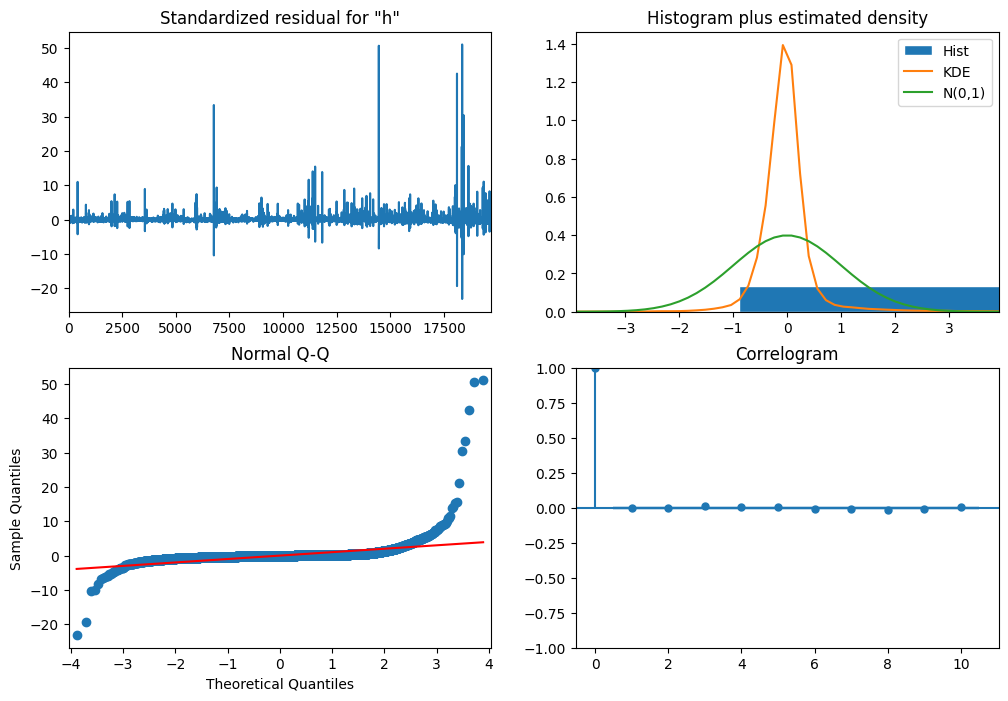

In [20]:
run_diagnostics(final_fit, "ARIMA")

## Residual Diagnostics Interpretation

The residual diagnostics indicate that the model is not fully adequate.

- The Ljung–Box test yields a very small p-value (< 0.05), indicating that residuals are not independent and still contain autocorrelation.
- The residual time series shows periods of high volatility and several large spikes, suggesting that the model fails to capture extreme price movements.
- The Q–Q plot reveals heavy tails and strong deviations from normality, indicating that the model does not handle outliers effectively.
- The histogram confirms a non-normal residual distribution with high kurtosis.

Overall, these results suggest that the model does not fully capture the underlying dynamics of the electricity price series. This is likely due to the presence of nonlinear patterns and external factors that are not adequately modeled by classical statistical approaches.

## SARIMA

SARIMA extends ARIMA by introducing seasonal terms.

Based on the EDA, daily seasonality is explicitly modeled using a seasonal period of 24 hours.

In [14]:
def tune_sarima(train_series, val_series, orders, seasonal_orders, horizon=1):
    best_rmse = float("inf")
    best_order = None
    best_seasonal_order = None
    rows = []

    for order in orders:
        for seasonal_order in seasonal_orders:
            try:
                model = sm.tsa.SARIMAX(
                    train_series,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                fitted = model.fit(disp=False)

                val_forecast = forecast_for_horizons_recursive(
                    fitted_model=fitted,
                    steps=len(val_series)
                )

                horizon_eval = evaluate_horizon(val_series, val_forecast, horizon)
                mae = horizon_eval["mae"]
                rmse = horizon_eval["rmse"]

                rows.append({
                    "order": order,
                    "seasonal_order": seasonal_order,
                    "horizon": horizon,
                    "mae": mae,
                    "rmse": rmse,
                    "aic": fitted.aic
                })

                print(f"SARIMA{order}x{seasonal_order}, horizon={horizon} -> val RMSE={rmse:.4f}")

                if rmse < best_rmse:
                    best_rmse = rmse
                    best_order = order
                    best_seasonal_order = seasonal_order

            except Exception:
                continue

    results_df = pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)
    return best_order, best_seasonal_order, best_rmse, results_df

In [16]:


orders = list(itertools.product([0, 1, 2, 3], [0, 1], [0, 1, 2, 3]))

seasonal_orders = [
    (0, 0, 0, 24),
    (1, 0, 0, 24),
    (0, 0, 1, 24),
    (1, 0, 1, 24),
    (0, 1, 0, 24),
    (1, 1, 0, 24),
    (0, 1, 1, 24),
    (1, 1, 1, 24)
]

sarima_best_configs = {}
sarima_tuning_tables = {}

for h in [1, 2, 3]:
    best_order, best_seasonal, best_rmse, tuning_df = tune_sarima(
        train_series, val_series, orders, seasonal_orders, horizon=h
    )

    sarima_best_configs[h] = {
        "order": best_order,
        "seasonal_order": best_seasonal
    }
    sarima_tuning_tables[h] = tuning_df

    print(f"\nBest SARIMA for horizon {h}: {best_order} x {best_seasonal}, validation RMSE={best_rmse:.4f}")

SARIMA(0, 0, 0)x(0, 0, 0, 24), horizon=1 -> val RMSE=90.6855
SARIMA(0, 0, 0)x(1, 0, 0, 24), horizon=1 -> val RMSE=90.3739
SARIMA(0, 0, 0)x(0, 0, 1, 24), horizon=1 -> val RMSE=90.6537
SARIMA(0, 0, 0)x(1, 0, 1, 24), horizon=1 -> val RMSE=70.9564
SARIMA(0, 0, 0)x(0, 1, 0, 24), horizon=1 -> val RMSE=72.6077
SARIMA(0, 0, 0)x(1, 1, 0, 24), horizon=1 -> val RMSE=74.1916
SARIMA(0, 0, 0)x(0, 1, 1, 24), horizon=1 -> val RMSE=70.2752
SARIMA(0, 0, 0)x(1, 1, 1, 24), horizon=1 -> val RMSE=70.4258
SARIMA(0, 0, 1)x(0, 0, 0, 24), horizon=1 -> val RMSE=90.6853
SARIMA(0, 0, 1)x(1, 0, 0, 24), horizon=1 -> val RMSE=90.5281
SARIMA(0, 0, 1)x(0, 0, 1, 24), horizon=1 -> val RMSE=90.6584
SARIMA(0, 0, 1)x(1, 0, 1, 24), horizon=1 -> val RMSE=70.8814
SARIMA(0, 0, 1)x(0, 1, 0, 24), horizon=1 -> val RMSE=72.6713
SARIMA(0, 0, 1)x(1, 1, 0, 24), horizon=1 -> val RMSE=74.2798
SARIMA(0, 0, 1)x(0, 1, 1, 24), horizon=1 -> val RMSE=70.3930
SARIMA(0, 0, 1)x(1, 1, 1, 24), horizon=1 -> val RMSE=70.5696
SARIMA(0, 0, 2)x(0, 0, 0

KeyboardInterrupt: 